# Correlation

In [1]:
# Correlation, Distribution Shapes, Hypothesis Basics

# Correlation - Pearson Vs Spearman

# df.corr()

Correlation measures whether two numeric columns tend to move together. Does one going up mean to other tends to go up too? (positive correlation)

or does one going up cause the other to go down? (Negative correlation) 

or no relationship at all (Zero correlation) 

Correlation is always a number between -1 and +1

 +1 = perfectly move together

 -1 = perfectly move opposite

 0 = no relationship at all

In [2]:
import os
os.chdir("Data Sets")

In [3]:
import pandas as pd

df = pd.read_csv("all_athlete_games.csv", low_memory=False)
noc_summary = df.groupby("NOC").agg(
    total_entries=("Entry ID","count"),
    total_medals=("Medal", lambda x: x.notna().sum()),
    gold_medals=("Medal", lambda x: (x=="Gold").sum()),
    avg_age=("Age","mean"),
    unique_sports=("Sport", lambda x: x.nunique())
).reset_index()
noc_summary = noc_summary[noc_summary["total_entries"] > 20]
print(len(noc_summary))

217


In [4]:
# Pearson Correlation - measures linear relationship

# syntax - df.corr(method = "pearson")  (this is the default method)

print(noc_summary[["total_entries","total_medals"]].corr(method="pearson"))

# A pearson correlation of 0.915 is a strong positive linear relationship between how many athletes a country sends and how many medals it wins.

# Pearson measures how tightly points cluster around a straight line.

               total_entries  total_medals
total_entries       1.000000      0.915031
total_medals        0.915031      1.000000


In [5]:
# Spearman correlation measures rank based on relationships

print(noc_summary[["total_entries","total_medals"]].corr(method="spearman"))

# Spearman converts every value to its rank first and measures whether the ranks move together .

# It doesnot care whether the relationship is perfectly straight line only whether it is consistently increasing.

               total_entries  total_medals
total_entries       1.000000      0.897692
total_medals        0.897692      1.000000


In [6]:
import pandas as pd
import numpy as np

x =  np.array([1,2,3,4,5,6,7,8,9,10])
y = 2**x
print(y)

print("Pearson:",pd.Series(x).corr(pd.Series(y),method="pearson"))

print("Spearman:",pd.Series(x).corr(pd.Series(y),method="spearman"))

[   2    4    8   16   32   64  128  256  512 1024]
Pearson: 0.7988372426181231
Spearman: 0.9999999999999999


In [7]:
%pip install seaborn matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


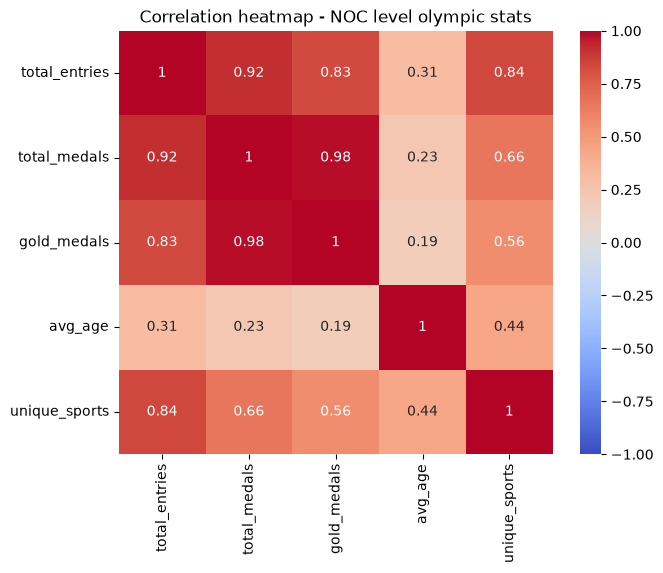

In [8]:
# df.corr() as a heatmap - seeing many relationships at once

# syntax - sns.heatmap[df.corr(),annot=True,cmap='coolwarm',vmin=-1,vmax=1]

import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = noc_summary[["total_entries","total_medals","gold_medals","avg_age","unique_sports"]].corr()

plt.figure(figsize=(7,5.5))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',vmin=-1,vmax=1)
plt.title("Correlation heatmap - NOC level olympic stats")
plt.show()

| Pair                          | Correlation | Interpretation                                        |
|------------------------------------|-----------------|----------------------------------------------------------------|
| total_entries vs total_medals            | 0.92                | Strong — more athletes sent, more medals won                       |
| total_medals vs gold_medals                 | 0.98                | Very strong — expected, gold medals are a SUBSET of total medals       |
| avg_age vs everything else                     | 0.19 – 0.44          | Weak — a country's typical athlete age has little to do with its medal count |
| total_entries vs unique_sports                    | 0.84                | Strong — countries competing in more entries also tend to compete across more sports |

# Part 2 - Distribution Shapes 

Distribution Shapes - normal, skewed,kurtosis

Distribution is the overall shape that your data forms when you plot it as a histogram.

Different shapes tell you different things about your data.

 Normal Distribution - the symmetric "bell curve"

Values cluster symmetrically around the mean-equally likely to be a bit above as a bit below, with extreme values rare on both sides.

 skew ~0 -> roughly symmetric (normal)

 skew >0 -> right skewed ( a long tail stretching towards higher values)

 skew <0 -> left skewed ( a long tail stretching towards lower values)

-0.0029949485350523985
Axes(0.125,0.11;0.775x0.77)


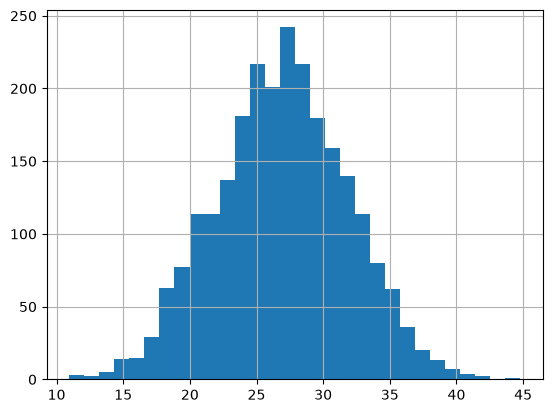

In [9]:
import numpy as np

normal_data = np.random.normal(27,5,2449)
print(pd.Series(normal_data).skew())
print(pd.Series(normal_data).hist(bins=30))

# A skewness near 0 confirms this is symmetric - no lean toward either side

2449
1.2087803333494522
Axes(0.125,0.11;0.775x0.77)


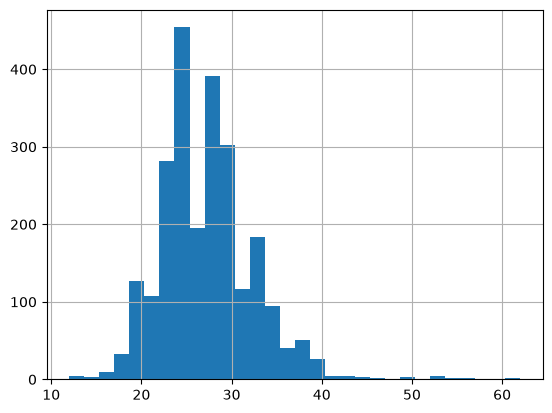

In [10]:
sample = df[(df["Year"]==2020) & (df["Medal"].notna())]
ages = sample["Age"].dropna()
print(len(ages))
print(ages.skew())

# A positive skew means age data is right skewed - most athletes cluster young with a long tail of older athletes stretching to the right.

print(ages.hist(bins=30))

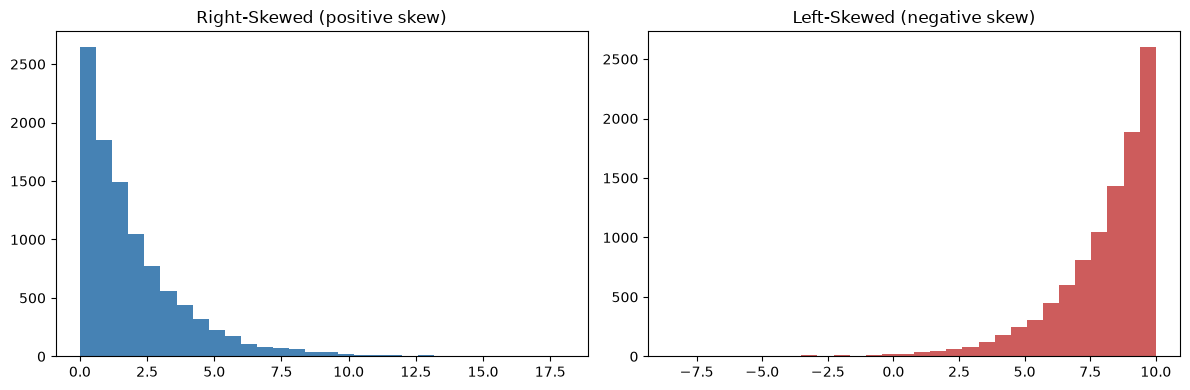

In [11]:
#Skewness - measuring which direction a distribution leans

import matplotlib.pyplot as plt

np.random.seed(1)
right_skewed_example = np.random.exponential(scale=2, size=10000)     # long tail to the RIGHT
left_skewed_example = 10 - np.random.exponential(scale=2, size=10000)  # long tail to the LEFT

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(right_skewed_example, bins=30, color='steelblue')
axes[0].set_title('Right-Skewed (positive skew)')
axes[1].hist(left_skewed_example, bins=30, color='indianred')
axes[1].set_title('Left-Skewed (negative skew)')
plt.tight_layout()
plt.show()

# Kurtosis

In [12]:
# Kurtosis - "Tail heaviness"

# syntax -series.kurt()

# A normal distribution scores 0

print(ages.kurt())

# A kurtosis of 4.46(well above 0) means this data is leptokurtic - more extreme values in the tails than a normal distribution predicts.

# This agrees with exactly 45 outliers found earlier - high kurtosis is a signal of more extreme values than expected.

4.456637869762883


| Kurtosis (excess)  | Name           | Meaning                                              |
|-------------------------|--------------------|--------------------------------------------------------------|
| Near 0                       | Mesokurtic             | Tail heaviness similar to normal                                    |
| Positive (> 0)                  | Leptokurtic               | Heavier tails — MORE extreme outliers than normal                     |
| Negative (< 0)                     | Platykurtic                 | Lighter tails — FEWER extreme outliers, more evenly spread                |

In [13]:
#Kurtosis- measuring how heavy the tails are

#Skewness tells you which direction a distribution leans.
#Kurtosis tells you how likely are extreme values 
# compared to what a normal distribution would predict

#Two distributions can be both perfectly symmetric(skew~0) and still look
#very different- one might have almost no extreme outliers,
# while another has surprisingly many,
# even while both are centered and shaped similarly in the middle

#The reference point: normal distribution~0

np.random.seed(1)
normal=pd.Series(np.random.normal(loc=25,scale=5,size=10000))
print(normal.kurt())

#close to 0 since normal was constructed to actually be normal,
# its kurtosis landed near the reference point

#The reading scale for kurtosis value:
#~0 - Tails behave like a normal distribution
#>0 (positive,"leptokurtic")- Heavier tails
# - extreme values happen more often than a normal distribution predicts

#<0 (negative,"platykurtic") - Lighter tails
# -extreme values happen less often than a normal distribution predicts

print(ages.kurt())

#A large positive number- age has heavier tails 
# than a normal bell curve would predict.
#Genuinely extreme ages,very young teenagers 
# and competitors in their 70s-90s show up more often in this dataset
# than you'd expect if ages were distributed in a plain well-behaved bell curve

0.02928411766794703
4.456637869762883


# Part 3 - Hypothesis

In [14]:
# Hypothesis

# what a p value means?

# You observe a difference between two groups - is it real? or could it just be random luck from which athletes happened to compete?

# The p-value asks "if there were truly no real difference how surprising would a difference this big, just by chance?"

# small p value = very surprising by chance - > can't confidently claim a real difference

# standard threshold : p<0.05 is conventionally "statistically significant"

In [19]:
# For example if in this dataset

# Gold medalists have an average age of 25.96 while non medalists have an average age of 25.61

# Is this a genuine pattern in the world, or could it just be random luck- the particular group of athletes who happened to end up in this dataset
# 
# So if you had a totally different, equally sized sample of olympic athletes
# would you expect to see roughly the same gap again? or could this gap easily been produced by pure chance
#  even if there is no real difference between medalists and non-medalists

# A hypothesis test is a formal,
# repeatable procedure for answering that question 
# with a number,instead of just guessing based on a gut feeling


# Hypotheis testing- two competing hyposthesis

# Every hypothesis test starts by writing down two opposite claims,

# Null hypothesis(H0):"There is no real difference-
# any gap we see is just due to random chance/sampling"

# Alternative hypothesis(H1): "There is a real difference"

# The test doesnt prove the alternative hypothesis is true
# Instead it works backwards-it assumes null hypothesis is true, and then checks how surprising your actual observed data would be under that assumption

In [20]:
# In a courtroom the defendant is assumed innocent until proven guilty. The prosecution has to present evidence strong enough to overcome that assumption.

# Hypothesis testing works the same way - you assume "no real difference" until the data gives you strong enough evidence to say otherwise

# Example 2:

# Do boxing medalists and Equestrian medalists have genuinely different average ages or could the age gap we see just to be random luck based on which specific athletes happened to compete?

# H0 : Boxing and Equestrian medalists have same average age (the difference we observe is just chance)

# H1 : Boxing and Equestrian medalists have different average ages (something real is going on)

# We never actually prove H1 true - we only ask is the evidence against H0 strong enough to reject it?


In [22]:
# Before runnig a test, you pick a cutoff - conventionally alpha = 0.05(5%)

# If your p-value is below this threshold you reject H0 and conclude the difference is likely real if its above you fail to reject H0 - you dont have strong enough evidence to claim a real differnce

# "Fail to reject H0" is not the same as H0 is true just means your data didnt provide strong enough evidence either way.

| p-value vs α = 0.05      | Decision                                          |
|-------------------------------|--------------------------------------------------------|
| p < 0.05                          | Reject H₀ — "statistically significant" difference          |
| p ≥ 0.05                            | Fail to reject H₀ — not enough evidence of a real difference   |

In [21]:
%pip install scipy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [23]:
import pandas as pd
from scipy import stats

df = pd.read_csv("all_athlete_games.csv", low_memory=False)
sample = df[(df["Year"]==2020) & (df["Medal"].notna())]

In [28]:
print(sample[sample["Sport"]=="Boxing"][["Age"]].mean())
print(sample[sample["Sport"]=="Equestrian"][["Age"]].mean())

# 52 Boxing medalists averaging 26.6 years old

# 43 Equestrian medalists averaging 42.4 old 

# That is a 15.8 year age gap between the two sports.

# Is that a real genuine pattern about these sports or could it be random luck about which specific 52 boxers and 43 Equestrians happened to compete and medal that particular year?

# Step 1 - start skeptical on purpose

# You assume "There's no real age difference between boxing and equestrian athletes in general" and this 15.8 year gap I found is just a coincidence or random luck from this particular sample of athletes

Age    26.634615
dtype: float64
Age    42.395349
dtype: float64
